In [13]:
import warnings
warnings.filterwarnings("ignore")

In [16]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy import stats
from skimage.io import imread
from skimage.transform import resize
from skimage.color import rgb2gray, rgb2hsv
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops, shannon_entropy
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from skimage.feature import blob_log
from skimage.filters import gaussian
from sklearn.ensemble import HistGradientBoostingClassifier # The "95% Secret Weapon"
import numpy as np
from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.svm import SVC
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
# --- 1. FEATURE EXTRACTION ENGINE ---

import numpy as np
import cv2
import os

def extract_features(img_path, size=(128, 128)):
    try:
        # Load image with OpenCV (loads as BGR)
        img_bgr = cv2.imread(img_path)
        if img_bgr is None: return None
        img_bgr = cv2.resize(img_bgr, size)
        
        # ==========================================
        # 1. COLOR NORMALIZATION (Gray World)
        # Fixes the "purple vs red vs whitish" issue
        # ==========================================
        b, g, r = cv2.split(img_bgr)
        m_b, m_g, m_r = np.mean(b), np.mean(g), np.mean(r)
        
        # Find the average gray value of the whole image
        m = (m_b + m_g + m_r) / 3.0
        
        # Prevent division by zero
        if m_b == 0 or m_g == 0 or m_r == 0: return None

        # Scale channels so the average color becomes neutral gray/pink
        b_norm = np.clip(b * (m / m_b), 0, 255).astype(np.uint8)
        g_norm = np.clip(g * (m / m_g), 0, 255).astype(np.uint8)
        r_norm = np.clip(r * (m / m_r), 0, 255).astype(np.uint8)
        img_norm = cv2.merge((b_norm, g_norm, r_norm))
        
        # ==========================================
        # 2. CREATE A CELL MASK
        # ==========================================
        gray_norm = cv2.cvtColor(img_norm, cv2.COLOR_BGR2GRAY)
        # Background is black, so we threshold to find the cell
        _, cell_mask = cv2.threshold(gray_norm, 10, 255, cv2.THRESH_BINARY)
        
        # ==========================================
        # 3. ADAPTIVE SPOT DETECTION
        # ==========================================
        # Parasites show up best as DARK spots in the GREEN channel.
        # adaptiveThreshold looks at a 21x21 pixel neighborhood.
        # It flags a pixel ONLY if it is noticeably darker than its immediate neighbors.
        local_thresh = cv2.adaptiveThreshold(
            g_norm, 
            255, 
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
            cv2.THRESH_BINARY_INV, 
            21,  # Neighborhood size
            5    # Constant subtracted from the mean (controls sensitivity)
        )
        
        # Only keep spots that are INSIDE the cell mask
        actual_spots = cv2.bitwise_and(local_thresh, cell_mask)
        
        # Morphological Opening: Erase tiny single-pixel "dust" artifacts
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        actual_spots = cv2.morphologyEx(actual_spots, cv2.MORPH_OPEN, kernel)
        
        # ==========================================
        # 4. MEASURE THE SPOTS
        # ==========================================
        # Find continuous blobs of spots
        contours, _ = cv2.findContours(actual_spots, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        num_spots = len(contours)
        
        if num_spots > 0:
            areas = [cv2.contourArea(c) for c in contours]
            max_spot_area = max(areas)
            total_spot_area = sum(areas)
            
            # Find how "Saturated" the spots are (parasites are highly colored)
            img_hsv = cv2.cvtColor(img_norm, cv2.COLOR_BGR2HSV)
            saturation_channel = img_hsv[:, :, 1]
            
            # Mask just the biggest spot to check its color intensity
            c_max = contours[np.argmax(areas)]
            max_spot_mask = np.zeros_like(gray_norm)
            cv2.drawContours(max_spot_mask, [c_max], -1, 255, -1)
            
            spot_saturation = np.mean(saturation_channel[max_spot_mask == 255])
        else:
            max_spot_area = 0
            total_spot_area = 0
            spot_saturation = 0

        # Return our highly robust features
        return np.array([
            num_spots,           # Are there any sharp, localized dots?
            max_spot_area,       # How big is the main dot?
            total_spot_area,     # Are there multiple tiny dots (like image 178)?
            spot_saturation,     # Is the dot a dense color (parasite) or pale (shadow)?
            np.std(gray_norm[cell_mask == 255]) # Overall texture of the cell
        ])

    except Exception as e:
        # print(f"Failed on {img_path}: {e}")
        return None

# --- 2. DATA LOADING ---

def load_data(root_dir):
    X, y = [], []
    class_names = sorted(os.listdir(root_dir))
    
    print(f"Extracting features from {root_dir}...")
    for label_idx, cls_name in enumerate(class_names):
        cls_path = os.path.join(root_dir, cls_name)
        if not os.path.isdir(cls_path): continue
        
        files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        for fname in tqdm(files, desc=f"Class: {cls_name}"):
            f_vector = extract_features(os.path.join(cls_path, fname))
            if f_vector is not None:
                X.append(f_vector)
                y.append(label_idx)
                
    return np.array(X), np.array(y)

# --- 3. EXECUTION PIPELINE ---
def run_evaluation(root_path):
    # 1. Load and Extract
    X, y = load_data(root_path) # Assuming this is defined elsewhere
    
    # 2. Define Models
    models = {
        "SVM": SVC(kernel='rbf', C=10, gamma='scale'), 
        "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1, max_depth=5),
        "Random Forest": RandomForestClassifier(n_estimators=200)
    }
        
    # 3. Setup 20-Fold Cross-Validation
    cv = StratifiedKFold(n_splits=20, shuffle=True, random_state=42)
    results = {}

    print("\nStarting 20-Fold Cross-Validation...")
    for name, model in models.items():
        # Pipeline ensures scaling is done separately for each fold (prevents data leakage)
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', model)
        ])
        
        cv_results = cross_validate(pipeline, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
        results[name] = cv_results['test_score']
        
        # We'll print the detailed stats in the next block instead to keep it clean

    # 4. STATISTICAL SIGNIFICANCE & STABILITY (95% CI & One-Sample T-Test)
    print("\n--- Model Stability & 95% Confidence Intervals ---")
    
    # Baseline accuracy for binary classification (blind guessing)
    baseline_chance = 0.50 
    
    for name, scores in results.items():
        n_folds = len(scores)
        mean_acc = np.mean(scores)
        
        # Calculate Sample Standard Deviation
        std_acc = np.std(scores, ddof=1) 
        
        # Calculate 95% Confidence Interval
        # stats.sem calculates the Standard Error of the Mean
        ci_lower, ci_upper = stats.t.interval(
            confidence=0.95, 
            df=n_folds - 1, 
            loc=mean_acc, 
            scale=stats.sem(scores)
        )
        
        # One-Sample T-Test: Is this model stably beating random chance?
        t_stat, p_val = stats.ttest_1samp(scores, popmean=baseline_chance, alternative='greater')
        
        sig = "Stable & Significant" if p_val < 0.05 else "Unstable / Not Significant"
        
        print(f"{name}:")
        print(f"  Accuracy : {mean_acc:.4f} ± {std_acc:.4f} (Std Dev)")
        print(f"  95% CI   : [{ci_lower:.4f}, {ci_upper:.4f}]")
        print(f"  p-value  : {p_val:.5e} ({sig})\n")

# Usage:
# run_evaluation('path/to/your/dataset')

In [17]:
run_evaluation('./cell_images')

Extracting features from ./cell_images...


Class: Uninfected: 100%|██████████| 13779/13779 [00:13<00:00, 1040.29it/s]



Starting 20-Fold Cross-Validation...

--- Model Stability & 95% Confidence Intervals ---
SVM:
  Accuracy : 0.9487 ± 0.0065 (Std Dev)
  95% CI   : [0.9457, 0.9518]
  p-value  : 6.74440e-37 (Stable & Significant)

HistGradientBoosting:
  Accuracy : 0.9495 ± 0.0058 (Std Dev)
  95% CI   : [0.9468, 0.9522]
  p-value  : 6.47091e-38 (Stable & Significant)

Random Forest:
  Accuracy : 0.9446 ± 0.0066 (Std Dev)
  95% CI   : [0.9415, 0.9476]
  p-value  : 1.04304e-36 (Stable & Significant)



In [19]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

def visualize_extraction_steps(img_path, size=(128, 128)):
    # Load image with OpenCV (loads as BGR)
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print(f"Could not load image at {img_path}")
        return
        
    img_bgr = cv2.resize(img_bgr, size)
    
    # Matplotlib expects RGB, so we convert the original for plotting
    img_rgb_original = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # ==========================================
    # 1. COLOR NORMALIZATION
    # ==========================================
    b, g, r = cv2.split(img_bgr)
    m_b, m_g, m_r = np.mean(b), np.mean(g), np.mean(r)
    m = (m_b + m_g + m_r) / 3.0

    if m_b != 0 and m_g != 0 and m_r != 0:
        b_norm = np.clip(b * (m / m_b), 0, 255).astype(np.uint8)
        g_norm = np.clip(g * (m / m_g), 0, 255).astype(np.uint8)
        r_norm = np.clip(r * (m / m_r), 0, 255).astype(np.uint8)
        img_norm = cv2.merge((b_norm, g_norm, r_norm))
    else:
        img_norm = img_bgr.copy()
        g_norm = g

    img_rgb_norm = cv2.cvtColor(img_norm, cv2.COLOR_BGR2RGB)
    
    # ==========================================
    # 2. CREATE A CELL MASK
    # ==========================================
    gray_norm = cv2.cvtColor(img_norm, cv2.COLOR_BGR2GRAY)
    _, cell_mask = cv2.threshold(gray_norm, 10, 255, cv2.THRESH_BINARY)
    
    # ==========================================
    # 3. ADAPTIVE SPOT DETECTION
    # ==========================================
    local_thresh = cv2.adaptiveThreshold(
        g_norm, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY_INV, 21, 5
    )
    
    # Mask out the background
    masked_thresh = cv2.bitwise_and(local_thresh, cell_mask)
    
    # Morphological Opening
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    actual_spots = cv2.morphologyEx(masked_thresh, cv2.MORPH_OPEN, kernel)
    
    # ==========================================
    # 4. MEASURE THE SPOTS (Draw Contours)
    # ==========================================
    contours, _ = cv2.findContours(actual_spots, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Draw the found contours in bright neon green on the normalized image
    img_with_contours = img_rgb_norm.copy()
    cv2.drawContours(img_with_contours, contours, -1, (0, 255, 0), 1)

    # ==========================================
    # PLOT EVERYTHING
    # ==========================================
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f"Algorithm Steps for: {os.path.basename(img_path)}", fontsize=16)

    # Plot 1: Original
    axes[0, 0].imshow(img_rgb_original)
    axes[0, 0].set_title("1. Original Image")
    axes[0, 0].axis('off')

    # Plot 2: Normalized
    axes[0, 1].imshow(img_rgb_norm)
    axes[0, 1].set_title("2. Color Normalized (Gray World)")
    axes[0, 1].axis('off')

    # Plot 3: Green Channel
    axes[0, 2].imshow(g_norm, cmap='gray')
    axes[0, 2].set_title("3. Green Channel (High Contrast)")
    axes[0, 2].axis('off')

    # Plot 4: Adaptive Threshold
    axes[1, 0].imshow(local_thresh, cmap='gray')
    axes[1, 0].set_title("4. Raw Adaptive Threshold")
    axes[1, 0].axis('off')

    # Plot 5: Final Cleaned Spots
    axes[1, 1].imshow(actual_spots, cmap='gray')
    axes[1, 1].set_title("5. Cleaned Spots (Masked + Opened)")
    axes[1, 1].axis('off')

    # Plot 6: Final Contours
    axes[1, 2].imshow(img_with_contours)
    axes[1, 2].set_title(f"6. Final Detections (Found {len(contours)} spots)")
    axes[1, 2].axis('off')

    plt.tight_layout()
    plt.show()


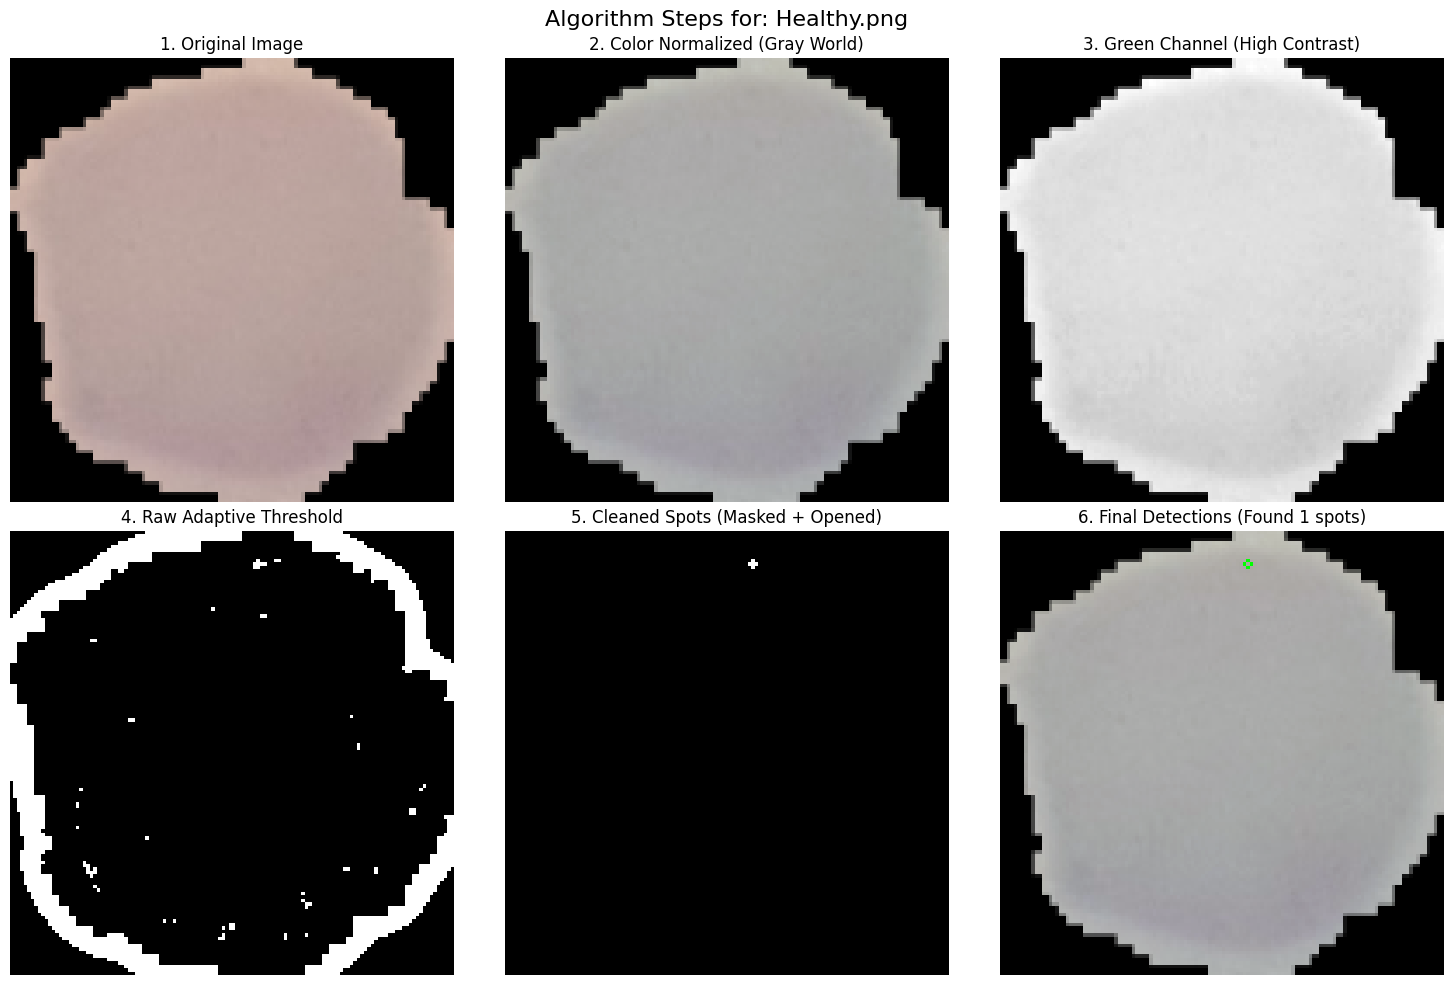

In [22]:
# How to use it:
visualize_extraction_steps('./Healthy.png')

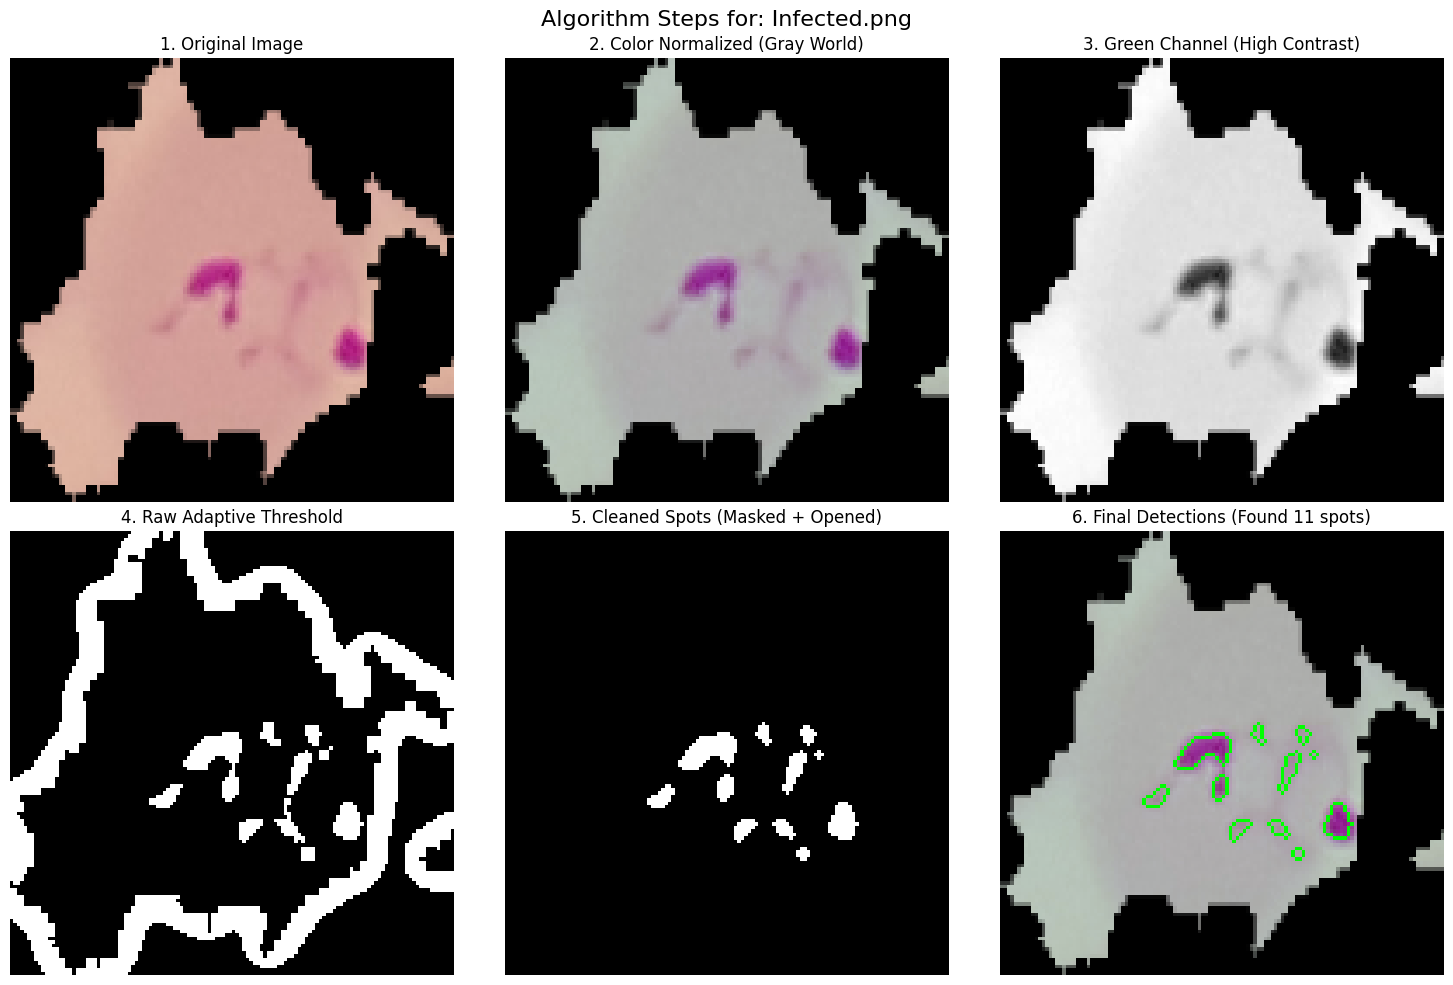

In [24]:
# How to use it:
visualize_extraction_steps('./Infected.png')

Loading data and extracting features...

Training Model for Error Analysis...
Total Test Samples: 5512
False Positives (Healthy classified as Parasitized): 145
False Negatives (Parasitized classified as Healthy): 168


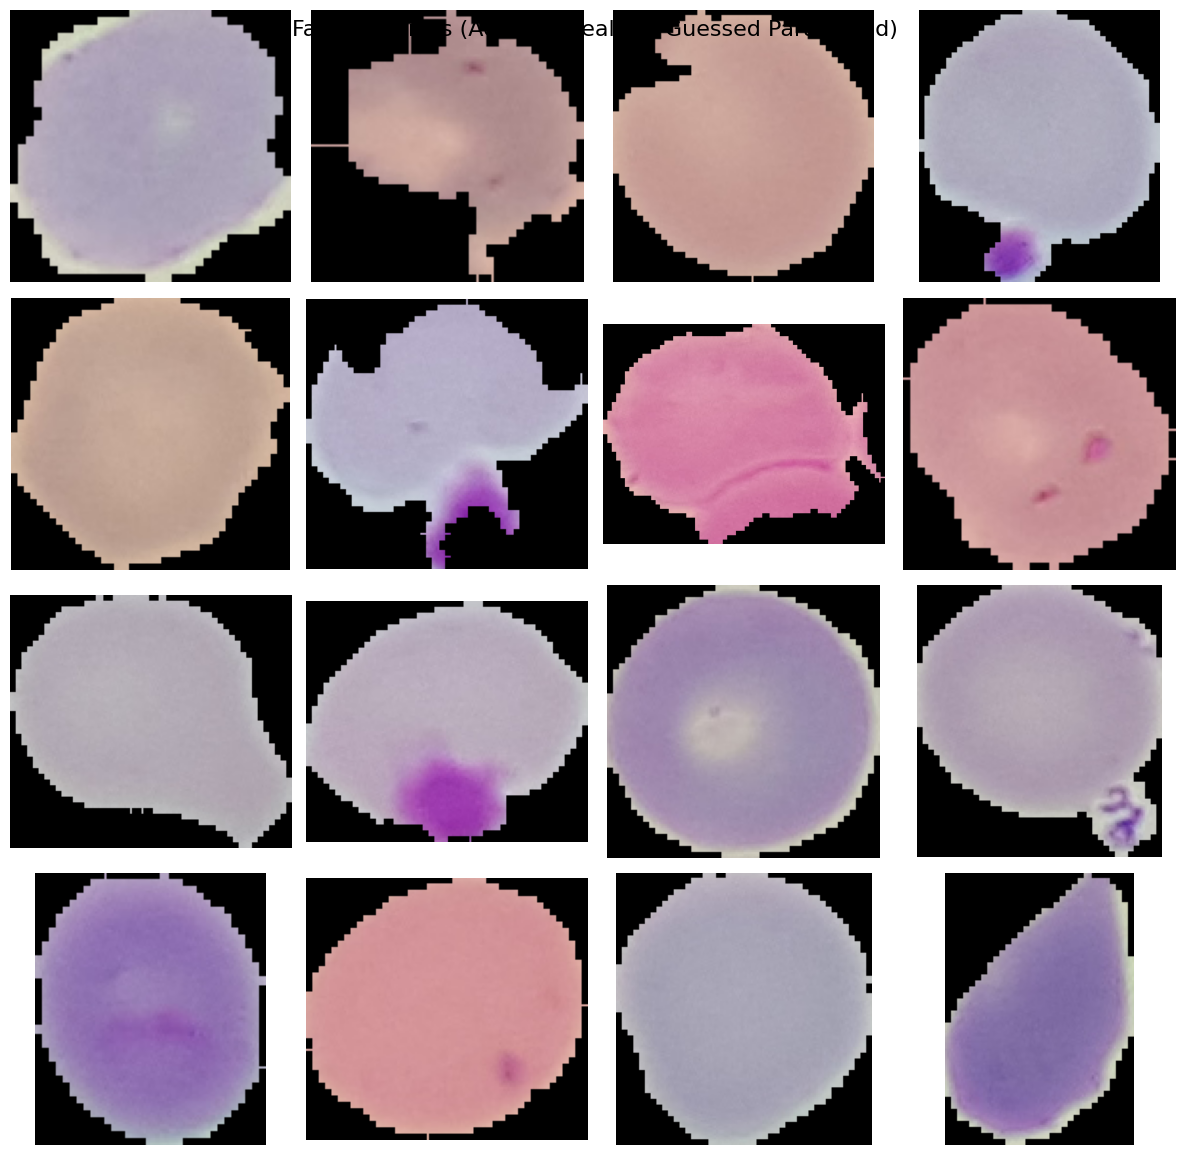

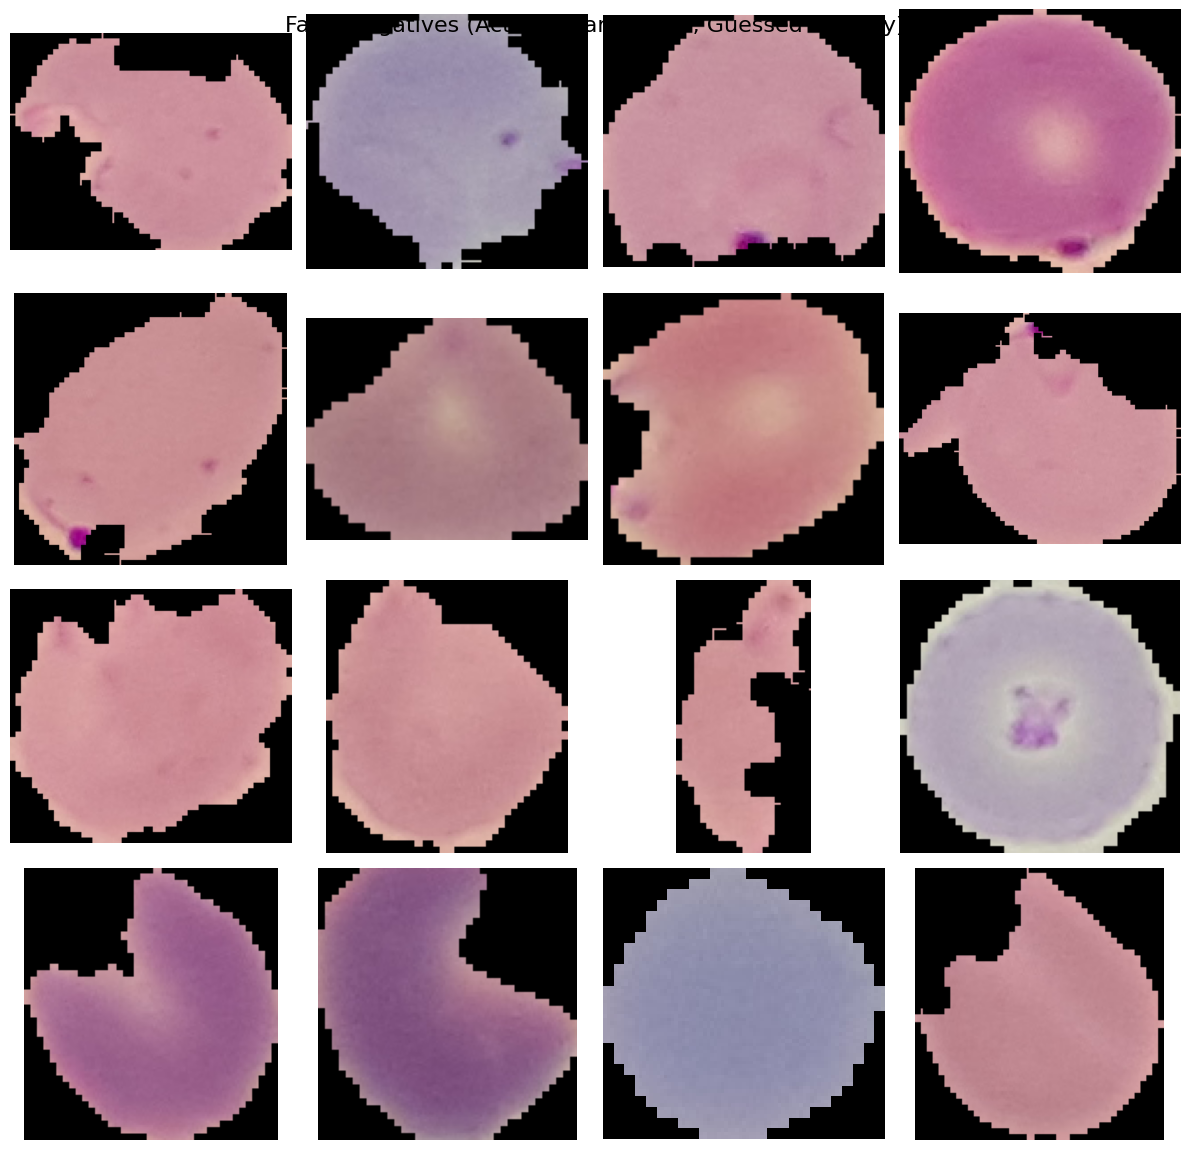

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Assuming 'load_data' and 'extract_features' are from your previous steps.
# Make sure to use the feature extractor that gave you the 86% accuracy for this test.

def analyze_failures(root_dir):
    print("Loading data and extracting features...")
    # 1. Load data and keep track of file paths so we can plot them later
    X, y, file_paths = [], [], []
    class_names = sorted(os.listdir(root_dir))
    
    # Note: Alphabetically, "Parasitized" is index 0, "Uninfected" is index 1
    for label_idx, cls_name in enumerate(class_names):
        cls_path = os.path.join(root_dir, cls_name)
        if not os.path.isdir(cls_path): continue
        
        files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg'))]
        for fname in files: # You can slice this to files[:2000] for a faster debug run
            full_path = os.path.join(cls_path, fname)
            f_vector = extract_features(full_path) # Use your best extractor here
            if f_vector is not None:
                X.append(f_vector)
                y.append(label_idx)
                file_paths.append(full_path)
                
    X = np.array(X)
    y = np.array(y)
    file_paths = np.array(file_paths)

    # 2. Train/Test Split
    X_train, X_test, y_train, y_test, paths_train, paths_test = train_test_split(
        X, y, file_paths, test_size=0.2, random_state=42, stratify=y
    )

    # 3. Train a single model
    print("\nTraining Model for Error Analysis...")
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
    ])
    model.fit(X_train, y_train)
    
    # 4. Predict and Find Errors
    y_pred = model.predict(X_test)
    
    # Identify indices of mistakes
    false_positives = np.where((y_test == 1) & (y_pred == 0))[0] # Assuming 1=Uninfected, 0=Parasitized
    false_negatives = np.where((y_test == 0) & (y_pred == 1))[0] 

    print(f"Total Test Samples: {len(y_test)}")
    print(f"False Positives (Healthy classified as Parasitized): {len(false_positives)}")
    print(f"False Negatives (Parasitized classified as Healthy): {len(false_negatives)}")

    # 5. Visualize the Errors
    plot_failed_cases(paths_test[false_positives], "False Positives (Actually Healthy, Guessed Parasitized)")
    plot_failed_cases(paths_test[false_negatives], "False Negatives (Actually Parasitized, Guessed Healthy)")


def plot_failed_cases(image_paths, title, num_images=16):
    """Plots a grid of failed images to visually inspect them."""
    if len(image_paths) == 0:
        print(f"No images to show for {title}")
        return
        
    plt.figure(figsize=(12, 12))
    plt.suptitle(title, fontsize=16, y=0.95)
    
    display_count = min(len(image_paths), num_images)
    for i in range(display_count):
        plt.subplot(4, 4, i + 1)
        img = plt.imread(image_paths[i])
        plt.imshow(img)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# Run the analysis
analyze_failures('./cell_images/')